# Banking on Behaviour - Starter Notebook

This notebook shows you how to load the data and create a valid submission.

Feature engineering, model selection, and validation strategy are up to you.

**Target:** Predict `next_3m_txn_count` for each customer in Test.csv

**Metric:** RMSLE (Root Mean Squared Logarithmic Error)

## 1. Load Data

In [1]:
import pandas as pd
import numpy as np

# Core files
train = pd.read_csv('../data/raw/Train.csv')
test = pd.read_csv('../data/raw/Test.csv')


train.head()
train.shape

(8360, 2)

<Axes: >

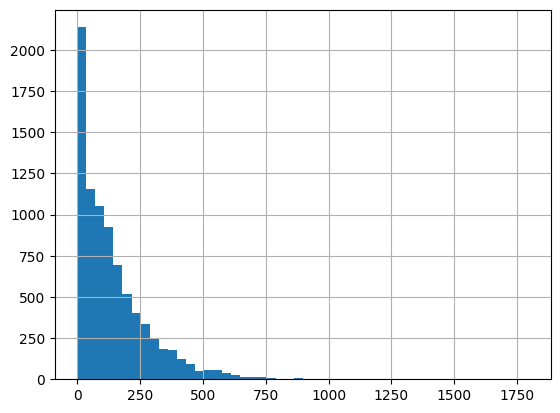

In [2]:
#Understanding the target
train['next_3m_txn_count'].describe()

#checking for missing values
train.isnull().sum() #no missing values

#analysing the skewness of the target variable
train['next_3m_txn_count'].hist(bins=50)

## 2. Explore the Feature Files

In [3]:
# Transaction history (18M rows - this may take a moment)
txn = pd.read_parquet('../data/raw/transactions_features.parquet')

#sampling the data just for analysing to understsandiut
txn_sample = txn.sample(200000, random_state=42)
txn_sample['UniqueID'].nunique() #how many unique customeers in transaction

#msut conbvert transactions → customer-level features
txn_sample.groupby('UniqueID').size().describe()


txn_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200000 entries, 1829124 to 16006956
Data columns (total 9 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   UniqueID                     200000 non-null  string        
 1   AccountID                    200000 non-null  string        
 2   TransactionDate              200000 non-null  datetime64[ns]
 3   TransactionAmount            200000 non-null  float64       
 4   TransactionTypeDescription   200000 non-null  object        
 5   TransactionBatchDescription  200000 non-null  object        
 6   StatementBalance             200000 non-null  float64       
 7   IsDebitCredit                200000 non-null  object        
 8   ReversalTypeDescription      200000 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(4), string(2)
memory usage: 15.3+ MB


In [4]:
#Understanding money behaviour
#grup by customer, select tarnsaction amount and sum the money customer has transacted from Dec 2012 → Oct 2015
#then get summary fo money behaviour
txn_sample.groupby("UniqueID")["TransactionAmount"].sum().describe()

count    1.089200e+04
mean    -3.122280e+03
std      2.442992e+05
min     -3.069872e+06
25%     -3.551698e+04
50%     -1.329420e+03
75%      1.813861e+04
max      3.155528e+06
Name: TransactionAmount, dtype: float64

<Axes: >

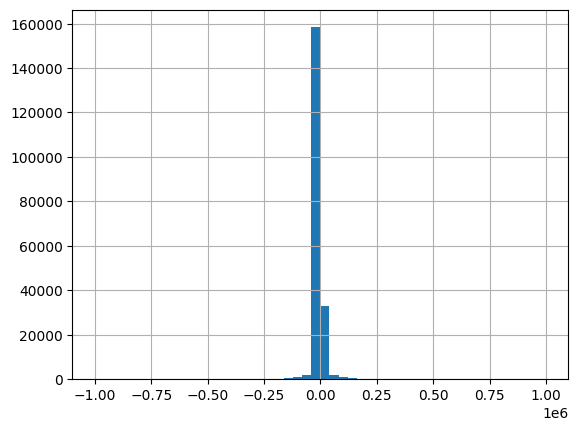

In [5]:
#looking at distribution of transaction amount
txn_sample['TransactionAmount'].hist(bins=50)

In [6]:
# Financial snapshots
# fin = pd.read_parquet('financials_features.parquet')
# print(f'Financials: {len(fin):,} rows, {fin.UniqueID.nunique():,} customers')
# print()
# print(fin.head())

In [7]:
# Demographics (one row per customer)
# demo = pd.read_parquet('demographics_clean.parquet')
# print(f'Demographics: {len(demo):,} rows')
# print()
# print(demo.head())

## 3. Your Work Goes Here

This is where you build your solution. Some things to think about:

- How will you aggregate 18M transaction rows into customer-level features?
- Which columns are most useful? Which ones need cleaning?
- How does the prediction window relate to the feature data?
- What modelling approach will you use?

## Stage 1: Use Transactions data only
- Learn behaviour
- Building basic model
- keep creating features and improving model


In [8]:
# Your feature engineering
# Building customer level features
customer_features = txn.groupby("UniqueID").agg({
    "TransactionAmount":["count", "sum", "mean", "std"]}).reset_index()


#renaming
customer_features.columns = [
    "UniqueID",
    "txn_count",
    "txn_total_amount",
    "txn_avg_amount",
    "txn_std_amount"
]
customer_features.head()

#merging feature to tarin data
#this will be my modelling dataset
train_merged = train.merge(customer_features, on="UniqueID", how="left")
train_merged.head()

#handling some missing values
train_merged.isnull().sum()
train_merged = train_merged.fillna(0)



In [9]:
# Your model training
#building my first very basica model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

x = train_merged[["txn_count", "txn_total_amount", "txn_avg_amount", "txn_avg_amount",
    "txn_std_amount"]]
y = train_merged["next_3m_txn_count"]

X_train, X_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train,y_train)

# Your predictions
y_pred = model.predict(X_val)

#evaluate using RMSLE(the metric)
rmsle = np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_val))**2))
rmsle



/tmp/ipykernel_16488/1367932084.py:19: RuntimeWarning: invalid value encountered in log1p
  rmsle = np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_val))**2))


np.float64(0.6851684942358508)

In [10]:
train_merged.head()

,UniqueID,next_3m_txn_count,txn_count,txn_total_amount,txn_avg_amount,txn_std_amount
0,00093e2d-9e1e-4061-ad27-a79b8ff9e165,129,1562,-894563.40,-572.703841,88833.409077
1,0011d60f-a4e2-4333-81fc-2d557a82109b,16,251,-2000656.68,-7970.743745,132902.058472
2,0016f1e2-64c1-4c65-a668-1dc6bf3b5875,117,44,-127.16,-2.890000,3.039344
3,001aa3c5-632d-435e-a421-cc3615ccef4d,70,340,87729.20,258.027059,89647.208240
4,00298c6f-4f9d-4f28-b72c-ad0e56e9eb84,393,2136,44110.45,20.650960,9755.953589


#### Basic regression model evaluation(stage 1 of my model building)
- The RMSLE is weak. Which is expected.
- But I have built the baseline
- My model doesn't know:
    - When transactions happened (time)
    - Whether behaviour is increasing/decreasing
    - Consistency over time
    - Recency (recent activity vs old)

In [11]:
## New feature: How recent was last transaction
#get the most recent transation date per customer
# reset_index() converts the result into a proper DataFrame
last_txn = txn.groupby('UniqueID')['TransactionDate'].max().reset_index()

#just going to remoe other columsn for clarity
last_txn.columns = ['UniqueID', 'last_txn_date']

# Get latest date in dataset (reference point)
max_date = txn['TransactionDate'].max()

# Calculate inactivity (days since last transaction)
last_txn['days_since_last_txn'] = (max_date - last_txn['last_txn_date']).dt.days

#merge this into train  dataset
train_merged = train_merged.merge(last_txn[['UniqueID', 'days_since_last_txn']], on='UniqueID', how='left')

In [12]:
train_merged.head()
#fill missing values with na
train_merged = train_merged.fillna(999)

In [13]:
#retarin model with new featuyre
x = train_merged[["txn_count", "txn_total_amount", "txn_avg_amount",
    "txn_std_amount","days_since_last_txn"]]
y = train_merged["next_3m_txn_count"]

X_train, X_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train,y_train)

# Your predictions
y_pred = model.predict(X_val)

#evaluate using RMSLE(the metric)
rmsle = np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_val))**2))
rmsle

/tmp/ipykernel_16488/157656708.py:15: RuntimeWarning: invalid value encountered in log1p
  rmsle = np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_val))**2))


np.float64(0.6799485937490058)

### "days_since_last_txn" feature insights
- The rmsle improved by ~0.009 when thsi feature was added.
- Therefore the feature is meaningfule, relevant and helping the model learn
- Therefore I just proved: Customers who transacted recently are more likely to transact again
- What behaviour am I still missing? Comsistency over time (how consistently they transact)



In [14]:
#extracting year-month from date
txn['year_month'] = txn['TransactionDate'].dt.to_period('M')
train_merged.head()

,UniqueID,next_3m_txn_count,txn_count,txn_total_amount,txn_avg_amount,txn_std_amount,days_since_last_txn
0,00093e2d-9e1e-4061-ad27-a79b8ff9e165,129,1562,-894563.40,-572.703841,88833.409077,0
1,0011d60f-a4e2-4333-81fc-2d557a82109b,16,251,-2000656.68,-7970.743745,132902.058472,4
2,0016f1e2-64c1-4c65-a668-1dc6bf3b5875,117,44,-127.16,-2.890000,3.039344,2
3,001aa3c5-632d-435e-a421-cc3615ccef4d,70,340,87729.20,258.027059,89647.208240,1
4,00298c6f-4f9d-4f28-b72c-ad0e56e9eb84,393,2136,44110.45,20.650960,9755.953589,0


In [15]:
train_merged.head()

,UniqueID,next_3m_txn_count,txn_count,txn_total_amount,txn_avg_amount,txn_std_amount,days_since_last_txn
0,00093e2d-9e1e-4061-ad27-a79b8ff9e165,129,1562,-894563.40,-572.703841,88833.409077,0
1,0011d60f-a4e2-4333-81fc-2d557a82109b,16,251,-2000656.68,-7970.743745,132902.058472,4
2,0016f1e2-64c1-4c65-a668-1dc6bf3b5875,117,44,-127.16,-2.890000,3.039344,2
3,001aa3c5-632d-435e-a421-cc3615ccef4d,70,340,87729.20,258.027059,89647.208240,1
4,00298c6f-4f9d-4f28-b72c-ad0e56e9eb84,393,2136,44110.45,20.650960,9755.953589,0


### Changing the model

I built a baseline model using Linear Regression with features derived from transaction data.

Even after adding new features (active_months), the model performance (RMSLE) did not improve consistently and sometimes got worse.

**Now I am swicthing to a more powerful model**
Switch to:
**LightGBM (Gradient Boosting Model)**

In [23]:
#importing LightGBM model
from lightgbm import LGBMRegressor

#features
x = train_merged[
    ["txn_count", "txn_total_amount", "txn_avg_amount","txn_std_amount",
     "days_since_last_txn"]
]

#target
y = train_merged["next_3m_txn_count"]
X_train, X_val, y_train, y_val = train_test_split(
    x, y,
    test_size=0.2,      # 20% for validation
    random_state=42     # ensures same split every time
)

#creating the model
# Create the model
model = LGBMRegressor(
    n_estimators=100,   # number of trees (more = more complex model)
    learning_rate=0.1,  # how fast the model learns
    random_state=42     # reproducibility
)
#training the model
model.fit(X_train, y_train)
#make predictions
y_pred = model.predict(X_val)
# Ensure no negative predictions (RMSLE cannot handle negatives)
y_pred = np.maximum(y_pred, 0)

# Calculate RMSLE
rmsle = np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_val))**2))

print("LightGBM RMSLE:", rmsle)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000113 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1075
[LightGBM] [Info] Number of data points in the train set: 6688, number of used features: 5
[LightGBM] [Info] Start training from score 145.296202
LightGBM RMSLE: 0.6339860245604472


In [24]:
fin = pd.read_parquet("../data/raw/financials_features.parquet")
fin.head()

,UniqueID,AccountID,RunDate,Product,NetInterestIncome,NetInterestRevenue
0,dcfae6b7-0c88-40dc-96aa-601df13c075f,5ead03e0-5048-4a9a-8947-f8e9c6482a73,2014-04-29,Transactional,-110.39,638.19
1,a6b8878b-ed4d-4836-8231-804ec1b2e787,<NA>,2015-08-26,Mortgages,448.58,68.42
2,fdaca0bc-ff5c-4622-b25f-423d558cff57,b1bdda89-d050-4de0-9e76-16d251aafe66,2015-08-01,Investments,-385.64,0.00
3,ad75f685-5893-4c7c-b165-5ca9e4da031f,49e6b7b3-c652-4036-a662-15f70e89cd79,2014-02-24,Investments,-89.08,0.00
4,388180f9-73c7-4f2f-a87b-ee9efd02d423,637dcfe7-bb5b-4b34-b451-31479851f487,2015-04-02,Transactional,5.59,581.56


In [23]:
fin.columns

Index(['UniqueID', 'AccountID', 'RunDate', 'Product', 'NetInterestIncome',
       'NetInterestRevenue'],
      dtype='object')

In [25]:
# Convert RunDate to datetime
fin["RunDate"] = pd.to_datetime(fin["RunDate"])

In [26]:
fin_features = fin.groupby("UniqueID").agg({
    "NetInterestIncome": ["mean", "sum", "std"],
    "NetInterestRevenue": ["mean", "sum", "std"]
}).reset_index()

# Clean column names
fin_features.columns = [
    "UniqueID",
    "avg_income", "total_income", "std_income",
    "avg_revenue", "total_revenue", "std_revenue"
]

In [27]:
# Number of unique products per customer
product_count = fin.groupby("UniqueID")["Product"].nunique().reset_index(name="num_products")

In [28]:
fin_features = fin_features.merge(product_count, on="UniqueID", how="left")

In [29]:
train_merged = train_merged.merge(fin_features, on="UniqueID", how="left")

train_merged = train_merged.fillna(0)

In [30]:
fin_features.head()


,UniqueID,avg_income,total_income,std_income,avg_revenue,total_revenue,std_revenue,num_products
0,00038178-a14e-468a-8053-a0edf5cf1b02,3727.372000,149094.88,4141.003339,318.233250,12729.33,254.931121,2
1,0006aac7-06d3-4fee-b0f6-11f57b9419e9,-222.245238,-4667.15,120.662735,537.300000,11283.30,209.899101,1
2,00093e2d-9e1e-4061-ad27-a79b8ff9e165,1304.165333,58687.44,2414.125438,236.619111,10647.86,216.713249,3
3,0011d60f-a4e2-4333-81fc-2d557a82109b,-1775.770476,-37291.18,3450.277593,975.380476,20482.99,1636.235696,1
4,0016f1e2-64c1-4c65-a668-1dc6bf3b5875,-2.015238,-42.32,0.428388,5.015714,105.33,1.252679,1


In [31]:
train_merged.columns

Index(['UniqueID', 'next_3m_txn_count', 'txn_count', 'txn_total_amount',
       'txn_avg_amount', 'txn_std_amount', 'days_since_last_txn',
       'recency_score', 'avg_income', 'total_income', 'std_income',
       'avg_revenue', 'total_revenue', 'std_revenue', 'num_products'],
      dtype='object')

In [32]:
x = train_merged[
    [
        "txn_count",
        "txn_total_amount",
        "txn_avg_amount",
        "txn_std_amount",
        "days_since_last_txn",

        "avg_income",
        "total_income",
        "std_income",
        "avg_revenue",
        "total_revenue",
        "std_revenue",
        "num_products"
    ]
]
#target
y = train_merged["next_3m_txn_count"]
from sklearn.model_selection import KFold
import numpy as np

# Create 5 different splits
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmsle_scores = []

# Loop through each split
for train_index, val_index in kf.split(x):
    
    X_train, X_val = x.iloc[train_index], x.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    
    model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=6,
    num_leaves=31,
    random_state=42
)
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_val)
    y_pred = np.maximum(y_pred, 0)
    
    rmsle = np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_val))**2))
    
    rmsle_scores.append(rmsle)

# Final result
print("CV RMSLE:", np.mean(rmsle_scores))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023514 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2609
[LightGBM] [Info] Number of data points in the train set: 6688, number of used features: 12
[LightGBM] [Info] Start training from score 145.296202
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

In [33]:
# Get importance values

importance = model.feature_importances_

# Create a DataFrame for readability
feature_importance = pd.DataFrame({
    "feature": x.columns,
    "importance": importance
})

# Sort by most important
feature_importance = feature_importance.sort_values(by="importance", ascending=False)

feature_importance

,feature,importance
0,txn_count,1806
3,txn_std_amount,802
9,total_revenue,568
1,txn_total_amount,567
7,std_income,546
8,avg_revenue,494
4,days_since_last_txn,467
10,std_revenue,465
5,avg_income,364
6,total_income,361


In [34]:
x = train_merged[
    [
        "txn_count",
        "txn_total_amount",
        "txn_avg_amount",
        "txn_std_amount",
        "days_since_last_txn",

        "avg_income",
        "total_income",
        "std_income",
        "avg_revenue",
        "total_revenue",
        "std_revenue",
        "num_products",
    ]
]
#target
y = train_merged["next_3m_txn_count"]
from sklearn.model_selection import KFold


# Create 5 different splits
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmsle_scores = []

# Loop through each split
for train_index, val_index in kf.split(x):
    
    X_train, X_val = x.iloc[train_index], x.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    
    model = LGBMRegressor(
    n_estimators=600,
    learning_rate=0.02,
    max_depth=-1,          # allow deeper trees
    num_leaves=50,         # more complex splits
    min_child_samples=20,  # allow smaller leaf nodes
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
    y_train_log = np.log1p(y_train)
    model.fit(X_train, y_train_log)
    
    # Predict in log space
    y_pred_log = model.predict(X_val)

    # Convert back to original scale
    y_pred = np.expm1(y_pred_log)

    # Avoid negatives
    y_pred = np.maximum(y_pred, 0)
    
    rmsle = np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_val))**2))
    
    rmsle_scores.append(rmsle)

# Final result
print("CV RMSLE:", np.mean(rmsle_scores))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002685 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2609
[LightGBM] [Info] Number of data points in the train set: 6688, number of used features: 12
[LightGBM] [Info] Start training from score 4.385629
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000267 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2607
[LightGBM] [Info] Number of data points in the train set: 6688, number of used features: 12
[LightGBM] [Info] Start training from score 4.382680
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000297 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2606
[LightGBM] [Info] Number of data points in the train set: 6688, number of used features: 12
[LightGBM] [Info] Start traini

In [35]:
model = LGBMRegressor(
    n_estimators=600,
    learning_rate=0.02,
    max_depth=-1,
    num_leaves=50,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# log transform target
y_log = np.log1p(y)

# train on FULL dataset
model.fit(x, y_log)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000198 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2614
[LightGBM] [Info] Number of data points in the train set: 8360, number of used features: 12
[LightGBM] [Info] Start training from score 4.386033


,boosting_type,'gbdt'
,num_leaves,50
,max_depth,-1
,learning_rate,0.02
,n_estimators,600
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## 4. Create a Valid Submission

Your submission must match the format of SampleSubmission.csv exactly.

In [ ]:
submission = pd.read_csv('SampleSubmission.csv')

# Replace this with your actual predictions
submission['next_3m_txn_count'] = train['next_3m_txn_count'].mean()

submission.to_csv('submission.csv', index=False)
print(f'Submission saved: {len(submission)} rows')
print(submission.head())

## Local Scoring

You can score your submission locally using the included evaluate.py script:



Note: PublicReference.csv is only available if you have it for local testing. On Zindi, scoring is automatic.